In [1]:
import torch
import cv2
import os
import sys

In [2]:
print("✅ PyTorch:", torch.__version__)
print("✅ CUDA:", torch.cuda.is_available())
print("✅ GPU:", torch.cuda.get_device_name(0))
print("✅ OpenCV:", cv2.__version__)
print("✅ Working directory:", os.getcwd())
print("\n🎉 Ready to build PPE Detection!")


✅ PyTorch: 2.5.1+cu121
✅ CUDA: True
✅ GPU: NVIDIA GeForce RTX 4060 Laptop GPU
✅ OpenCV: 4.13.0
✅ Working directory: c:\Users\malek\yolov9

🎉 Ready to build PPE Detection!


In [3]:
import os

DATASET_PATH = r"C:/Users/malek/Downloads/archive (3)/images"

print("Dataset path:", DATASET_PATH)

Dataset path: C:/Users/malek/Downloads/archive (3)/images


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

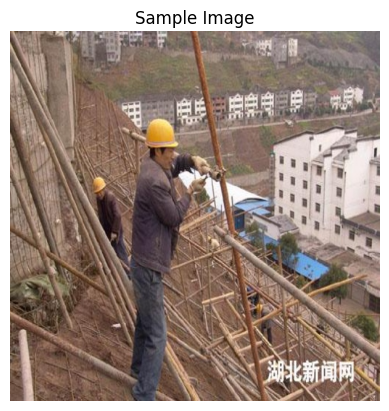

In [4]:
import cv2
import matplotlib.pyplot as plt

img_path = r"C:/Users/malek/Downloads/archive (3)/images/train/000001.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Sample Image")
plt.axis("off")

In [6]:
import os
hyps = os.listdir('data/hyps')
print(hyps)

['hyp.scratch-high.yaml']


In [7]:
# Fix — Create correct ppe.yaml
yaml_content = """path: C:/Users/malek/yolov9/datasets/ppe
train: images/train
val: images/vali
test: images/test

nc: 3
names: ['Helmet', 'Vest', 'Head']
"""

with open('data/ppe.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ ppe.yaml created!")

# Verify
with open('data/ppe.yaml', 'r') as f:
    print(f.read())

✅ ppe.yaml created!
path: C:/Users/malek/yolov9/datasets/ppe
train: images/train
val: images/vali
test: images/test

nc: 3
names: ['Helmet', 'Vest', 'Head']



In [ ]:
# Cell 2 — Final fixed version
import subprocess, sys, os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

cmd = [
    sys.executable, "train.py",
    "--weights", "yolov9-c.pt",
    "--cfg", "models/detect/gelan-c.yaml",
    "--data", "data/ppe.yaml",
    "--hyp", "data/hyps/hyp.scratch-high.yaml",
    "--epochs", "20",
    "--batch", "8",
    "--imgsz", "480",
    "--device", "0",
    "--name", "ppe_final",
    "--workers", "2"
]

result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

In [11]:

with open('data/ppe.yaml', 'w', newline='\n') as f:
    f.write("path: C:/Users/malek/yolov9/datasets/ppe\n")
    f.write("train: images/train\n")
    f.write("val: images/val\n")
    f.write("test: images/test\n")
    f.write("\n")
    f.write("nc: 3\n")
    f.write("names: ['Helmet', 'Vest', 'Head']\n")

In [12]:
with open('data/ppe.yaml', 'r') as f:
    print(f.read())

path: C:/Users/malek/yolov9/datasets/ppe
train: images/train
val: images/val
test: images/test

nc: 3
names: ['Helmet', 'Vest', 'Head']



In [1]:
import subprocess, sys, os

# Force NVIDIA GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Check which GPU torch is using
import torch
print("Using GPU:", torch.cuda.get_device_name(0))
print("GPU Memory used:", round(torch.cuda.memory_allocated(0)/1024**3, 2), "GB")

Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Memory used: 0.0 GB


In [2]:
import os

# Check if training results exist
results_path = 'runs/train'
if os.path.exists(results_path):
    runs = os.listdir(results_path)
    print("Training runs found:", runs)
    
    # Check for best weights
    for run in runs:
        weights_path = f'runs/train/{run}/weights'
        if os.path.exists(weights_path):
            print(f"\n✅ {run}/weights:", os.listdir(weights_path))
else:
    print("❌ No training results found")

Training runs found: ['ppe_final', 'ppe_final2', 'ppe_model', 'ppe_model2', 'ppe_model3', 'ppe_model_v2', 'ppe_model_v3', 'ppe_model_v32']

✅ ppe_final/weights: []

✅ ppe_final2/weights: ['best.pt', 'last.pt']

✅ ppe_model/weights: []

✅ ppe_model2/weights: []

✅ ppe_model3/weights: []

✅ ppe_model_v2/weights: []

✅ ppe_model_v3/weights: []

✅ ppe_model_v32/weights: []


In [ ]:
# Cell 3 — Test detection on an image
import subprocess, sys

# Use the completed model
WEIGHTS = "runs/train/ppe_final2/weights/best.pt"

cmd = [
    sys.executable, "detect.py",
    "--weights", WEIGHTS,
    "--source", "datasets/ppe/images/test",  # test images
    "--imgsz", "480",
    "--conf", "0.25",
    "--device", "0",
    "--name", "ppe_test",
    "--save-txt",
    "--exist-ok"
]

process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in process.stdout:
    print(line, end='')
process.wait()
print("\n✅ Detection complete!")

KeyboardInterrupt: 

: 

In [4]:
import torch
ckpt = torch.load('runs/train/ppe_final2/weights/best.pt', map_location='cpu')
print("Trained epochs:", ckpt.get('epoch', 'unknown'))

C:\Users\malek\AppData\Local\Temp\ipykernel_16844\920604820.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('runs/train/ppe_final2/weights/best.pt', ma

Trained epochs: 5


In [ ]:
import os
print(os.listdir('runs/train/ppe_done/weights'))
# Should show: ['best.pt', 'last.pt']